In [1]:
"""Kaggle notebook cell: builds encounter-level 30-day readmission datasets

from CMS DE-SynPUF sample folders (including Inpatient, Outpatient,
Beneficiary 2008-2010, Prescription Drug Events, and Carrier Claims).

Outputs one processed CSV per folder (sample1.csv, sample2.csv, ...).
"""

from __future__ import annotations

from dataclasses import dataclass, field
import glob
import logging
import os
import re
from typing import Optional

import numpy as np
import pandas as pd

# --------------------------------------------------------------------------- #
# >>> EDIT PATHS FOR YOUR KAGGLE ENVIRONMENT <<<
# --------------------------------------------------------------------------- #
ROOT_DIR = "/kaggle/input/datasets/ibtehajali1/cms-dataset-samples/synpuf_data"  # Folder containing sample 1/, sample 2/, ...
OUT_DIR = "/kaggle/working/processed_samples"  # Output directory for processed CSVs
# --------------------------------------------------------------------------- #

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("readmission_pipeline")


# --------------------------------------------------------------------------- #
# Column Schemas (Memory-efficient disk loading)
# --------------------------------------------------------------------------- #

BENE_COLS = [
    "DESYNPUF_ID",
    "BENE_BIRTH_DT",
    "BENE_DEATH_DT",
    "BENE_SEX_IDENT_CD",
    "BENE_RACE_CD",
    "SP_STATE_CODE",
    "BENE_COUNTY_CD",
    "SP_ALZHDMTA",
    "SP_CHF",
    "SP_CHRNKIDN",
    "SP_CNCR",
    "SP_COPD",
    "SP_DEPRESSN",
    "SP_DIABETES",
    "SP_ISCHMCHT",
    "SP_OSTEOPRS",
    "SP_RA_OA",
    "SP_STRKETIA",
]

COMORBIDITY_COLS = [
    "SP_ALZHDMTA",
    "SP_CHF",
    "SP_CHRNKIDN",
    "SP_CNCR",
    "SP_COPD",
    "SP_DEPRESSN",
    "SP_DIABETES",
    "SP_ISCHMCHT",
    "SP_OSTEOPRS",
    "SP_RA_OA",
    "SP_STRKETIA",
]

ICD9_DGNS_COLS = [f"ICD9_DGNS_CD_{i}" for i in range(1, 11)]
ICD9_PRCDR_COLS = [f"ICD9_PRCDR_CD_{i}" for i in range(1, 7)]

INPATIENT_COLS = (
    [
        "DESYNPUF_ID",
        "CLM_ID",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "CLM_PMT_AMT",
        "NCH_BENE_IP_DDCTBL_AMT",
        "CLM_DRG_CD",
        "ADMTNG_ICD9_DGNS_CD",
    ]
    + ICD9_DGNS_COLS
    + ICD9_PRCDR_COLS
)

OUTPATIENT_COLS = ["DESYNPUF_ID", "CLM_FROM_DT", "CLM_PMT_AMT"]

PDE_COLS = ["DESYNPUF_ID", "SRVC_DT", "PROD_SRVC_ID", "TOT_RX_CST_AMT"]

CARRIER_COLS = ["DESYNPUF_ID", "CLM_FROM_DT"]

FINAL_COLUMN_ORDER = (
    [
        "DESYNPUF_ID",
        "CLM_ID",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "DAYS_TO_NEXT_ADMISSION",
        "READMITTED_30D",
        "AGE_AT_ADMISSION",
        "BENE_SEX_IDENT_CD",
        "BENE_RACE_CD",
        "SP_STATE_CODE",
        "BENE_COUNTY_CD",
    ]
    + COMORBIDITY_COLS
    + [
        "LENGTH_OF_STAY",
        "CLM_PMT_AMT",
        "NCH_BENE_IP_DDCTBL_AMT",
        "CLM_DRG_CD",
        "ADMTNG_ICD9_DGNS_CD",
    ]
    + ICD9_DGNS_COLS
    + ICD9_PRCDR_COLS
    + [
        "PRIOR_INPATIENT_STAYS_L1Y",
        "PRIOR_OUTPATIENT_VISIT_COUNT",
        "PRIOR_OUTPATIENT_PAYMENT_SUM",
        "PRIOR_RX_FILL_COUNT_180D",
        "PRIOR_DISTINCT_DRUGS_180D",
        "PRIOR_RX_TOTAL_SPEND_180D",
        "POLYPHARMACY_FLAG_180D",
        "PRIOR_CARRIER_VISIT_COUNT",
    ]
)


# --------------------------------------------------------------------------- #
# Folder / File Discovery
# --------------------------------------------------------------------------- #


@dataclass
class SampleFolderFiles:
    folder: str
    sample_tag: str
    beneficiary_paths: dict = field(default_factory=dict)  # year -> path
    inpatient_path: Optional[str] = None
    outpatient_path: Optional[str] = None
    pde_path: Optional[str] = None
    carrier_paths: list[str] = field(default_factory=list)


def _first_match(pattern: str) -> Optional[str]:
    matches = sorted(glob.glob(pattern))
    return matches[0] if matches else None


def discover_sample_folders(root_dir: str) -> list[SampleFolderFiles]:
    folders = []
    if not os.path.exists(root_dir):
        log.error("Root directory '%s' does not exist.", root_dir)
        return folders

    for entry in sorted(os.listdir(root_dir)):
        folder_path = os.path.join(root_dir, entry)
        if not os.path.isdir(folder_path):
            continue

        bene_paths = {}
        for year in (2008, 2009, 2010):
            p = _first_match(
                os.path.join(
                    folder_path,
                    f"*DE1_0_{year}_Beneficiary_Summary_File_Sample_*.csv",
                )
            )
            if p:
                bene_paths[year] = p

        inpatient_path = _first_match(
            os.path.join(
                folder_path, "*DE1_0_2008_to_2010_Inpatient_Claims_Sample_*.csv"
            )
        )
        outpatient_path = _first_match(
            os.path.join(
                folder_path,
                "*DE1_0_2008_to_2010_Outpatient_Claims_Sample_*.csv",
            )
        )
        pde_path = _first_match(
            os.path.join(
                folder_path,
                "*DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_*.csv",
            )
        )
        carrier_paths = sorted(
            glob.glob(
                os.path.join(
                    folder_path,
                    "*DE1_0_2008_to_2010_Carrier_Claims_Sample_*.csv",
                )
            )
        )

        if len(bene_paths) == 3 and inpatient_path and outpatient_path:
            folders.append(
                SampleFolderFiles(
                    folder=folder_path,
                    sample_tag=entry,
                    beneficiary_paths=bene_paths,
                    inpatient_path=inpatient_path,
                    outpatient_path=outpatient_path,
                    pde_path=pde_path,
                    carrier_paths=carrier_paths,
                )
            )
        else:
            log.warning(
                "Skipping '%s': missing core files (bene years=%s, inpatient=%s, outpatient=%s)",
                entry,
                sorted(bene_paths.keys()),
                bool(inpatient_path),
                bool(outpatient_path),
            )

    return folders


def output_name_for(sample_tag: str, fallback_index: int) -> str:
    match = re.search(r"(\d+)", sample_tag)
    number = match.group(1) if match else str(fallback_index)
    return f"sample{number}.csv"


# --------------------------------------------------------------------------- #
# Data Loaders
# --------------------------------------------------------------------------- #


def load_beneficiary_longitudinal(files: SampleFolderFiles) -> pd.DataFrame:
    frames = []
    for year, path in files.beneficiary_paths.items():
        df = pd.read_csv(
            path, usecols=BENE_COLS, dtype={"DESYNPUF_ID": "string"}
        )
        df["YEAR"] = year
        frames.append(df)
    bene = pd.concat(frames, ignore_index=True)

    bene["BENE_BIRTH_DT"] = pd.to_datetime(
        bene["BENE_BIRTH_DT"].astype(str), format="%Y%m%d", errors="coerce"
    )
    bene["BENE_DEATH_DT"] = pd.to_datetime(
        bene["BENE_DEATH_DT"]
        .fillna(0)
        .astype(np.int64)
        .astype(str)
        .replace("0", np.nan),
        format="%Y%m%d",
        errors="coerce",
    )

    for col in COMORBIDITY_COLS:
        bene[col] = (bene[col] == 1).astype("Int8")

    return bene


def build_death_lookup(bene_long: pd.DataFrame) -> pd.DataFrame:
    return (
        bene_long.dropna(subset=["BENE_DEATH_DT"])
        .drop_duplicates(subset="DESYNPUF_ID")[["DESYNPUF_ID", "BENE_DEATH_DT"]]
    )


def load_inpatient(files: SampleFolderFiles) -> pd.DataFrame:
    df = pd.read_csv(
        files.inpatient_path,
        usecols=INPATIENT_COLS,
        dtype={"DESYNPUF_ID": "string", "CLM_ID": "string"},
    )
    df["CLM_ADMSN_DT"] = pd.to_datetime(
        df["CLM_ADMSN_DT"].astype(str), format="%Y%m%d", errors="coerce"
    )
    df["NCH_BENE_DSCHRG_DT"] = pd.to_datetime(
        df["NCH_BENE_DSCHRG_DT"].astype(str), format="%Y%m%d", errors="coerce"
    )
    return df


def load_outpatient(files: SampleFolderFiles) -> pd.DataFrame:
    df = pd.read_csv(
        files.outpatient_path,
        usecols=OUTPATIENT_COLS,
        dtype={"DESYNPUF_ID": "string"},
    )
    df["CLM_FROM_DT"] = pd.to_datetime(
        df["CLM_FROM_DT"].astype(str), format="%Y%m%d", errors="coerce"
    )
    return df


def load_pde(pde_path: Optional[str]) -> pd.DataFrame:
    if not pde_path or not os.path.exists(pde_path):
        return pd.DataFrame(columns=PDE_COLS)
    df = pd.read_csv(
        pde_path,
        usecols=PDE_COLS,
        dtype={"DESYNPUF_ID": "string", "PROD_SRVC_ID": "string"},
    )
    df["SRVC_DT"] = pd.to_datetime(
        df["SRVC_DT"].astype(str), format="%Y%m%d", errors="coerce"
    )
    return df


def load_carrier(carrier_paths: list[str]) -> pd.DataFrame:
    frames = []
    for path in carrier_paths:
        if os.path.exists(path):
            df = pd.read_csv(
                path, usecols=CARRIER_COLS, dtype={"DESYNPUF_ID": "string"}
            )
            df["CLM_FROM_DT"] = pd.to_datetime(
                df["CLM_FROM_DT"].astype(str), format="%Y%m%d", errors="coerce"
            )
            frames.append(df)
    return (
        pd.concat(frames, ignore_index=True)
        if frames
        else pd.DataFrame(columns=CARRIER_COLS)
    )


# --------------------------------------------------------------------------- #
# Feature Engineering Modules
# --------------------------------------------------------------------------- #


def compute_readmission_target(inpatient: pd.DataFrame) -> pd.DataFrame:
    df = inpatient.dropna(
        subset=["CLM_ADMSN_DT", "NCH_BENE_DSCHRG_DT"]
    ).copy()

    invalid_timeline = df["NCH_BENE_DSCHRG_DT"] < df["CLM_ADMSN_DT"]
    n_invalid = int(invalid_timeline.sum())
    df = df.loc[~invalid_timeline].copy()

    df = df.sort_values(
        ["DESYNPUF_ID", "CLM_ADMSN_DT", "NCH_BENE_DSCHRG_DT"]
    ).reset_index(drop=True)

    df["NEXT_ADMISSION_DT"] = df.groupby("DESYNPUF_ID")["CLM_ADMSN_DT"].shift(
        -1
    )
    delta = (df["NEXT_ADMISSION_DT"] - df["NCH_BENE_DSCHRG_DT"]).dt.days
    df["DAYS_TO_NEXT_ADMISSION"] = delta

    df["READMITTED_30D"] = (
        ((delta >= 0) & (delta <= 30)).fillna(False).astype("Int8")
    )

    df.attrs["n_invalid_timeline_dropped"] = n_invalid
    return df.drop(columns=["NEXT_ADMISSION_DT"])


def compute_prior_inpatient_stays(df: pd.DataFrame) -> pd.Series:
    result = np.zeros(len(df), dtype="int32")
    admn = df["CLM_ADMSN_DT"].values.astype("datetime64[D]")
    ids = df["DESYNPUF_ID"].values

    start = 0
    n = len(df)
    while start < n:
        end = start + 1
        while end < n and ids[end] == ids[start]:
            end += 1
        group_dates = admn[start:end]
        window_start = group_dates - np.timedelta64(365, "D")
        lo = np.searchsorted(group_dates, window_start, side="left")
        idx = np.arange(len(group_dates))
        result[start:end] = idx - lo
        start = end

    return pd.Series(result, index=df.index, name="PRIOR_INPATIENT_STAYS_L1Y")


def apply_exclusions(
    df: pd.DataFrame, death_lookup: pd.DataFrame
) -> pd.DataFrame:
    merged = df.merge(death_lookup, on="DESYNPUF_ID", how="left")
    died_during_stay = merged["BENE_DEATH_DT"].notna() & (
        merged["BENE_DEATH_DT"] <= merged["NCH_BENE_DSCHRG_DT"]
    )
    n_dropped = int(died_during_stay.sum())
    log.info("  Excluding %d encounters for in-hospital mortality", n_dropped)
    return merged.loc[~died_during_stay].drop(columns=["BENE_DEATH_DT"])


def aggregate_outpatient(outpatient: pd.DataFrame) -> pd.DataFrame:
    df = outpatient.dropna(subset=["CLM_FROM_DT"]).copy()
    df["YEAR"] = df["CLM_FROM_DT"].dt.year
    return (
        df.groupby(["DESYNPUF_ID", "YEAR"])
        .agg(
            PRIOR_OUTPATIENT_VISIT_COUNT=("CLM_FROM_DT", "count"),
            PRIOR_OUTPATIENT_PAYMENT_SUM=("CLM_PMT_AMT", "sum"),
        )
        .reset_index()
    )


def compute_prescription_metrics(
    inpatient: pd.DataFrame, pde: pd.DataFrame
) -> pd.DataFrame:
    """Computes Part D pharmacy metrics strictly within 180 days prior to admission."""
    default_df = pd.DataFrame(
        {
            "CLM_ID": inpatient["CLM_ID"],
            "PRIOR_RX_FILL_COUNT_180D": 0,
            "PRIOR_DISTINCT_DRUGS_180D": 0,
            "PRIOR_RX_TOTAL_SPEND_180D": 0.0,
            "POLYPHARMACY_FLAG_180D": 0,
        }
    )

    if pde.empty or inpatient.empty:
        return default_df

    # Match pharmacy events strictly for hospitalized beneficiaries
    pde_sub = pde[pde["DESYNPUF_ID"].isin(inpatient["DESYNPUF_ID"])]
    if pde_sub.empty:
        return default_df

    merged = pd.merge(
        inpatient[["DESYNPUF_ID", "CLM_ID", "CLM_ADMSN_DT"]],
        pde_sub[["DESYNPUF_ID", "SRVC_DT", "PROD_SRVC_ID", "TOT_RX_CST_AMT"]],
        on="DESYNPUF_ID",
        how="inner",
    )

    diff = (merged["CLM_ADMSN_DT"] - merged["SRVC_DT"]).dt.days
    valid_window = (diff >= 0) & (diff <= 180)
    filtered = merged.loc[valid_window]

    agg = (
        filtered.groupby("CLM_ID")
        .agg(
            PRIOR_RX_FILL_COUNT_180D=("PROD_SRVC_ID", "count"),
            PRIOR_DISTINCT_DRUGS_180D=("PROD_SRVC_ID", "nunique"),
            PRIOR_RX_TOTAL_SPEND_180D=("TOT_RX_CST_AMT", "sum"),
        )
        .reset_index()
    )

    res = inpatient[["CLM_ID"]].merge(agg, on="CLM_ID", how="left").fillna(
        {
            "PRIOR_RX_FILL_COUNT_180D": 0,
            "PRIOR_DISTINCT_DRUGS_180D": 0,
            "PRIOR_RX_TOTAL_SPEND_180D": 0.0,
        }
    )
    res["POLYPHARMACY_FLAG_180D"] = (
        res["PRIOR_DISTINCT_DRUGS_180D"] >= 10
    ).astype("Int8")
    return res


def compute_carrier_metrics(
    inpatient: pd.DataFrame, carrier: pd.DataFrame
) -> pd.DataFrame:
    """Computes Part B outpatient physician visit counts in the admission year."""
    if carrier.empty or inpatient.empty:
        inpatient["PRIOR_CARRIER_VISIT_COUNT"] = 0
        return inpatient

    carrier_sub = carrier.dropna(subset=["CLM_FROM_DT"]).copy()
    carrier_sub["YEAR"] = carrier_sub["CLM_FROM_DT"].dt.year
    carrier_agg = (
        carrier_sub.groupby(["DESYNPUF_ID", "YEAR"])
        .agg(PRIOR_CARRIER_VISIT_COUNT=("CLM_FROM_DT", "count"))
        .reset_index()
    )

    inpatient = inpatient.merge(
        carrier_agg,
        left_on=["DESYNPUF_ID", "ADMISSION_YEAR"],
        right_on=["DESYNPUF_ID", "YEAR"],
        how="left",
    )
    inpatient["PRIOR_CARRIER_VISIT_COUNT"] = (
        inpatient["PRIOR_CARRIER_VISIT_COUNT"].fillna(0).astype("int32")
    )
    return inpatient


# --------------------------------------------------------------------------- #
# Per-Folder Processing Pipeline
# --------------------------------------------------------------------------- #


def process_folder(files: SampleFolderFiles) -> pd.DataFrame:
    log.info("Processing %s...", files.sample_tag)

    # 1. Load Files
    bene_long = load_beneficiary_longitudinal(files)
    death_lookup = build_death_lookup(bene_long)
    inpatient = load_inpatient(files)
    outpatient = load_outpatient(files)
    pde = load_pde(files.pde_path)
    carrier = load_carrier(files.carrier_paths)

    # 2. Inpatient Stays & Target Calculation
    ip = compute_readmission_target(inpatient)
    ip["PRIOR_INPATIENT_STAYS_L1Y"] = compute_prior_inpatient_stays(ip)
    ip = apply_exclusions(ip, death_lookup)

    # 3. Join Beneficiary Demographics
    ip["ADMISSION_YEAR"] = ip["CLM_ADMSN_DT"].dt.year
    ip = ip.merge(
        bene_long,
        left_on=["DESYNPUF_ID", "ADMISSION_YEAR"],
        right_on=["DESYNPUF_ID", "YEAR"],
        how="left",
    )

    # 4. Join Outpatient Claims
    op_agg = aggregate_outpatient(outpatient)
    ip = ip.merge(
        op_agg,
        left_on=["DESYNPUF_ID", "ADMISSION_YEAR"],
        right_on=["DESYNPUF_ID", "YEAR"],
        how="left",
        suffixes=("", "_op"),
    )
    ip["PRIOR_OUTPATIENT_VISIT_COUNT"] = (
        ip["PRIOR_OUTPATIENT_VISIT_COUNT"].fillna(0).astype("int32")
    )
    ip["PRIOR_OUTPATIENT_PAYMENT_SUM"] = ip[
        "PRIOR_OUTPATIENT_PAYMENT_SUM"
    ].fillna(0.0)

    # 5. Join Prescription Drug Events (180D Prior Window)
    pde_metrics = compute_prescription_metrics(ip, pde)
    ip = ip.merge(pde_metrics, on="CLM_ID", how="left")

    # 6. Join Carrier Claims
    ip = compute_carrier_metrics(ip, carrier)

    # 7. Engineer Age and Length of Stay
    ip["AGE_AT_ADMISSION"] = (
        (ip["CLM_ADMSN_DT"] - ip["BENE_BIRTH_DT"]).dt.days / 365.25
    ).round(1)
    ip["LENGTH_OF_STAY"] = (
        ip["NCH_BENE_DSCHRG_DT"] - ip["CLM_ADMSN_DT"]
    ).dt.days

    keep_cols = [c for c in FINAL_COLUMN_ORDER if c in ip.columns]
    return ip[keep_cols]


# --------------------------------------------------------------------------- #
# Summary & Orchestration
# --------------------------------------------------------------------------- #


def summarize(df: pd.DataFrame, label: str) -> None:
    total = len(df)
    positive = int(df["READMITTED_30D"].sum()) if total else 0
    ratio = positive / total if total else float("nan")
    poly = int(df["POLYPHARMACY_FLAG_180D"].sum()) if "POLYPHARMACY_FLAG_180D" in df.columns else 0
    log.info(
        "  [%s] rows=%d, unique patients=%d, readmit rate=%.4f, polypharmacy cases=%d",
        label,
        total,
        df["DESYNPUF_ID"].nunique(),
        ratio,
        poly,
    )


def run(root_dir: str, out_dir: str) -> dict[str, pd.DataFrame]:
    folders = discover_sample_folders(root_dir)
    if not folders:
        log.error("No valid sample folders found under %s", root_dir)
        raise SystemExit(1)
    log.info(
        "Found %d sample folder(s): %s",
        len(folders),
        [f.sample_tag for f in folders],
    )

    os.makedirs(out_dir, exist_ok=True)

    results: dict[str, pd.DataFrame] = {}
    for i, files in enumerate(folders, start=1):
        try:
            processed = process_folder(files)
        except Exception:
            log.exception(
                "Failed to process folder '%s' -- skipping it", files.sample_tag
            )
            continue

        out_name = output_name_for(files.sample_tag, fallback_index=i)
        out_path = os.path.join(out_dir, out_name)
        processed.to_csv(out_path, index=False)
        summarize(processed, out_name)
        log.info("  -> wrote %s (%d rows)", out_path, len(processed))
        results[out_name] = processed

    if not results:
        log.error("No folders processed successfully. Aborting.")
        raise SystemExit(1)

    log.info("Done. Wrote %d file(s) to %s", len(results), out_dir)
    return results


# Execute pipeline
if __name__ == "__main__":
    outputs = run(ROOT_DIR, OUT_DIR)

08:40:43 | INFO     | Found 20 sample folder(s): ['sample 1', 'sample 10', 'sample 11', 'sample 12', 'sample 13', 'sample 14', 'sample 15', 'sample 16', 'sample 17', 'sample 18', 'sample 19', 'sample 2', 'sample 20', 'sample 3', 'sample 4', 'sample 5', 'sample 6', 'sample 7', 'sample 8', 'sample 9']
08:40:43 | INFO     | Processing sample 1...
08:41:03 | INFO     |   Excluding 4 encounters for in-hospital mortality
08:41:08 | INFO     |   [sample1.csv] rows=66905, unique patients=37779, readmit rate=0.1004, polypharmacy cases=29108
08:41:08 | INFO     |   -> wrote /kaggle/working/processed_samples/sample1.csv (66905 rows)
08:41:08 | INFO     | Processing sample 10...
08:41:27 | INFO     |   Excluding 4 encounters for in-hospital mortality
08:41:31 | INFO     |   [sample10.csv] rows=66709, unique patients=37678, readmit rate=0.1000, polypharmacy cases=29042
08:41:31 | INFO     |   -> wrote /kaggle/working/processed_samples/sample10.csv (66709 rows)
08:41:31 | INFO     | Processing sampl

In [2]:
import glob
import pandas as pd

# --------------------------------------------------------------------------- #
FINAL_OUT_PATH = "/kaggle/working/final_merged_dataset.csv"
# --------------------------------------------------------------------------- #

sample_files = sorted(
    glob.glob(os.path.join(OUT_DIR, "sample*.csv")),
    key=lambda p: int(re.search(r"(\d+)", os.path.basename(p)).group(1))
)

if not sample_files:
    raise SystemExit(f"No sample*.csv files found in {OUT_DIR}")

log.info("Merging %d file(s): %s", len(sample_files), [os.path.basename(p) for p in sample_files])

frames = []
for path in sample_files:
    df = pd.read_csv(path, dtype={"DESYNPUF_ID": "string"})
    df["SOURCE_FILE"] = os.path.basename(path)   # keep provenance
    frames.append(df)

final_df = pd.concat(frames, ignore_index=True)
final_df.to_csv(FINAL_OUT_PATH, index=False)

log.info("Saved merged dataset to %s", FINAL_OUT_PATH)
log.info(
    "Final: rows=%d, unique patients=%d, readmit rate=%.4f",
    len(final_df), final_df["DESYNPUF_ID"].nunique(),
    final_df["READMITTED_30D"].mean(),
)

final_df.head()

08:57:29 | INFO     | Merging 20 file(s): ['sample1.csv', 'sample2.csv', 'sample3.csv', 'sample4.csv', 'sample5.csv', 'sample6.csv', 'sample7.csv', 'sample8.csv', 'sample9.csv', 'sample10.csv', 'sample11.csv', 'sample12.csv', 'sample13.csv', 'sample14.csv', 'sample15.csv', 'sample16.csv', 'sample17.csv', 'sample18.csv', 'sample19.csv', 'sample20.csv']
08:58:13 | INFO     | Saved merged dataset to /kaggle/working/final_merged_dataset.csv
08:58:13 | INFO     | Final: rows=1335333, unique patients=755176, readmit rate=0.1000


,DESYNPUF_ID,CLM_ID,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,DAYS_TO_NEXT_ADMISSION,READMITTED_30D,AGE_AT_ADMISSION,BENE_SEX_IDENT_CD,BENE_RACE_CD,SP_STATE_CODE,...,ICD9_PRCDR_CD_6,PRIOR_INPATIENT_STAYS_L1Y,PRIOR_OUTPATIENT_VISIT_COUNT,PRIOR_OUTPATIENT_PAYMENT_SUM,PRIOR_RX_FILL_COUNT_180D,PRIOR_DISTINCT_DRUGS_180D,PRIOR_RX_TOTAL_SPEND_180D,POLYPHARMACY_FLAG_180D,PRIOR_CARRIER_VISIT_COUNT,SOURCE_FILE
0,00013D2EFD8E45D1,196661176988405,2010-03-12,2010-03-13,NaN,0,86.9,1.0,1.0,26.0,...,NaN,0,0,0.0,31.0,31.0,1940.0,1,0,sample1.csv
1,00016F745862898F,196201177000368,2009-04-12,2009-04-18,135.0,0,66.3,1.0,1.0,39.0,...,NaN,0,0,0.0,5.0,5.0,540.0,0,0,sample1.csv
2,00016F745862898F,196661177015632,2009-08-31,2009-09-02,15.0,1,66.7,1.0,1.0,39.0,...,NaN,1,0,0.0,2.0,2.0,110.0,0,0,sample1.csv
3,00016F745862898F,196091176981058,2009-09-17,2009-09-20,279.0,0,66.7,1.0,1.0,39.0,...,NaN,2,0,0.0,2.0,2.0,110.0,0,0,sample1.csv
4,00016F745862898F,196261176983265,2010-06-26,2010-07-01,NaN,0,67.5,1.0,1.0,39.0,...,NaN,2,0,0.0,4.0,4.0,240.0,0,0,sample1.csv


In [4]:
final_df.columns

Index(['DESYNPUF_ID', 'CLM_ID', 'CLM_ADMSN_DT', 'NCH_BENE_DSCHRG_DT',
       'DAYS_TO_NEXT_ADMISSION', 'READMITTED_30D', 'AGE_AT_ADMISSION',
       'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'SP_STATE_CODE', 'BENE_COUNTY_CD',
       'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD',
       'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA',
       'SP_STRKETIA', 'LENGTH_OF_STAY', 'CLM_PMT_AMT',
       'NCH_BENE_IP_DDCTBL_AMT', 'CLM_DRG_CD', 'ADMTNG_ICD9_DGNS_CD',
       'ICD9_DGNS_CD_1', 'ICD9_DGNS_CD_2', 'ICD9_DGNS_CD_3', 'ICD9_DGNS_CD_4',
       'ICD9_DGNS_CD_5', 'ICD9_DGNS_CD_6', 'ICD9_DGNS_CD_7', 'ICD9_DGNS_CD_8',
       'ICD9_DGNS_CD_9', 'ICD9_DGNS_CD_10', 'ICD9_PRCDR_CD_1',
       'ICD9_PRCDR_CD_2', 'ICD9_PRCDR_CD_3', 'ICD9_PRCDR_CD_4',
       'ICD9_PRCDR_CD_5', 'ICD9_PRCDR_CD_6', 'PRIOR_INPATIENT_STAYS_L1Y',
       'PRIOR_OUTPATIENT_VISIT_COUNT', 'PRIOR_OUTPATIENT_PAYMENT_SUM',
       'PRIOR_RX_FILL_COUNT_180D', 'PRIOR_DISTINCT_DRUGS_180D',
       'PRIOR

Loading master dataset from /kaggle/working/final_merged_dataset.csv...
Running advanced feature engineering...
Starting 5-Fold Patient-Grouped CV on 1,335,333 encounters...
  Fold 1 | ROC-AUC: 0.7078 | PR-AUC: 0.1928
  Fold 2 | ROC-AUC: 0.7064 | PR-AUC: 0.1925
  Fold 3 | ROC-AUC: 0.7086 | PR-AUC: 0.1947
  Fold 4 | ROC-AUC: 0.7077 | PR-AUC: 0.1952
  Fold 5 | ROC-AUC: 0.7088 | PR-AUC: 0.1933

OUT-OF-FOLD PERFORMANCE EVALUATION
Overall ROC-AUC:      0.7079
Overall PR-AUC:       0.1936
Brier Score (Calib):  0.0856

Optimal Threshold: 0.1369 | Max F1-Score: 0.2774
              precision    recall  f1-score   support

           0     0.9338    0.7520    0.8331   1201761
           1     0.1891    0.5205    0.2774    133572

    accuracy                         0.7288   1335333
   macro avg     0.5615    0.6362    0.5553   1335333
weighted avg     0.8593    0.7288    0.7775   1335333



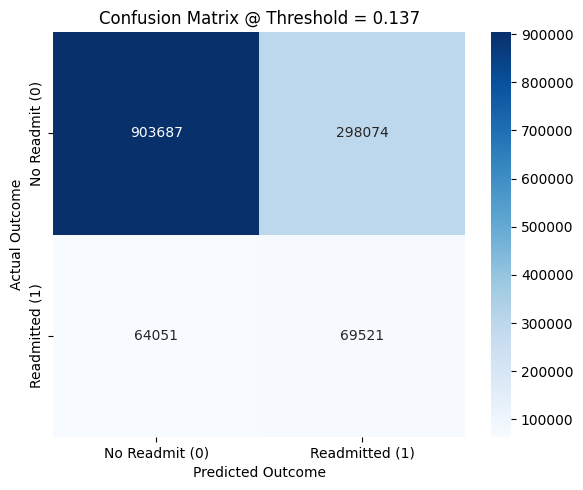


Computing TreeSHAP values for 3,000 sample encounters...


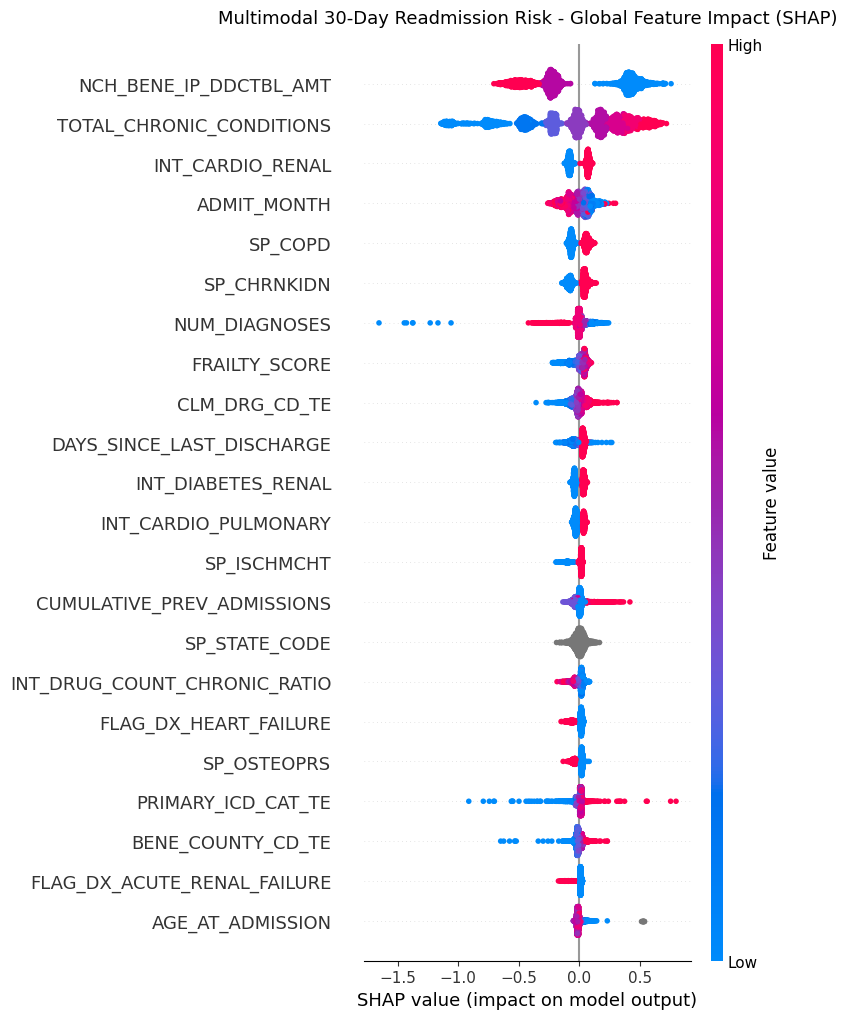

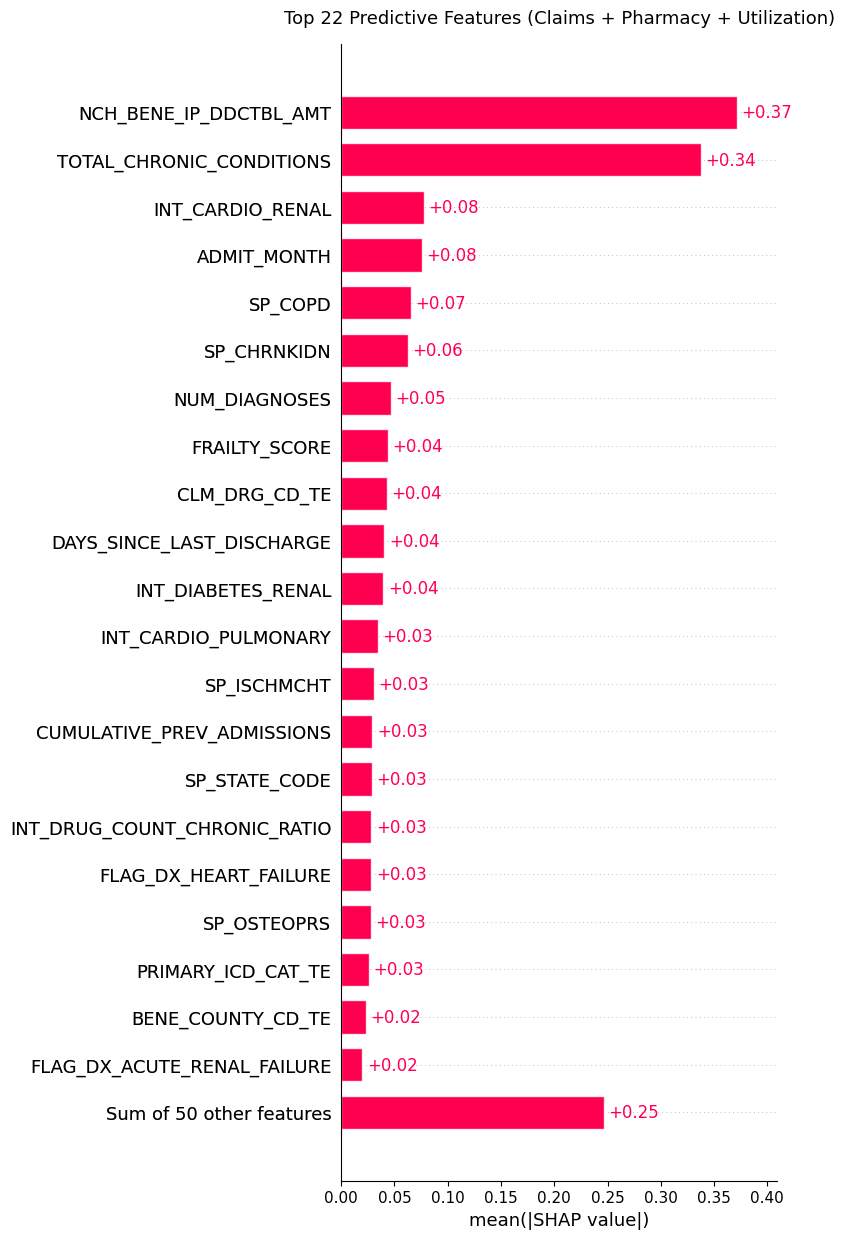

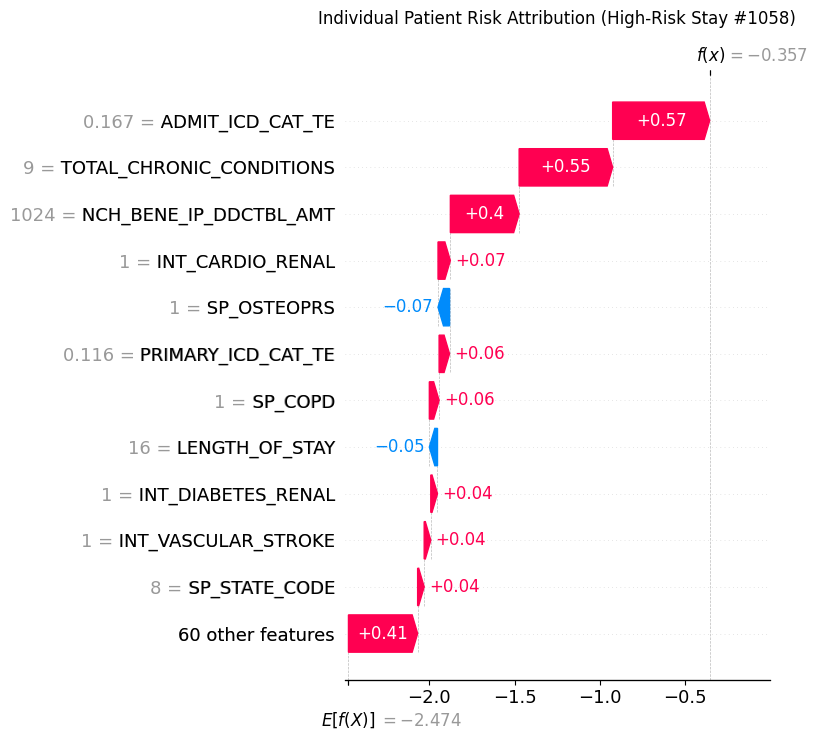

In [5]:
import os
import warnings
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
DATA_PATH = "/kaggle/working/final_merged_dataset.csv"
OUTPUT_DIR = "/kaggle/working/readmission_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

HIGH_RISK_DIAGNOSES = {
    "SEPSIS": "038",
    "HEART_FAILURE": "428",
    "ACUTE_RENAL_FAILURE": "584",
    "PNEUMONIA": "486",
    "COPD_FLARE": "491",
    "ELECTROLYTE_DISORDER": "276",
    "AMI": "410",
    "CHRONIC_ISCHEMIC_HD": "414",
    "UTI": "599",
    "STROKE_INFARCT": "434",
    "GI_BLEED": "578",
    "ASPIRATION_PNEUMONIA": "507",
}

HIGH_RISK_PROCEDURES = {
    "HEMODIALYSIS": "3995",
    "BLOOD_TRANSFUSION": "990",
    "VENTILATION_INTUBATION": "967",
    "CARDIAC_CATH": "372",
}


# -----------------------------------------------------------------------------
# 1. Advanced Feature Engineering & Multimodal Ingestion
# -----------------------------------------------------------------------------
def build_advanced_features(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Extracts longitudinal lookback velocity, Part D polypharmacy metrics,

    Part B ambulatory utilization, frailty indices, and multi-diagnosis flags.
    """
    df = df_raw.copy()

    # Parse timestamps for temporal sequence analysis
    if "CLM_ADMSN_DT" in df.columns:
        df["CLM_ADMSN_DT_PARSED"] = pd.to_datetime(
            df["CLM_ADMSN_DT"], errors="coerce"
        )
    if "NCH_BENE_DSCHRG_DT" in df.columns:
        df["NCH_BENE_DSCHRG_DT_PARSED"] = pd.to_datetime(
            df["NCH_BENE_DSCHRG_DT"], errors="coerce"
        )

    # 1. Longitudinal Patient Lookback Features
    if "CLM_ADMSN_DT_PARSED" in df.columns:
        df = df.sort_values(
            by=["DESYNPUF_ID", "CLM_ADMSN_DT_PARSED"]
        ).reset_index(drop=True)
        df["PREV_DSCHRG_DT"] = df.groupby("DESYNPUF_ID")[
            "NCH_BENE_DSCHRG_DT_PARSED"
        ].shift(1)
        df["DAYS_SINCE_LAST_DISCHARGE"] = (
            df["CLM_ADMSN_DT_PARSED"] - df["PREV_DSCHRG_DT"]
        ).dt.days.fillna(999.0)
        df["HAD_PRIOR_READMISSION_90D"] = (
            df["DAYS_SINCE_LAST_DISCHARGE"] <= 90
        ).astype(int)
        df["HAD_PRIOR_READMISSION_30D"] = (
            df["DAYS_SINCE_LAST_DISCHARGE"] <= 30
        ).astype(int)
        df["CUMULATIVE_PREV_ADMISSIONS"] = df.groupby("DESYNPUF_ID").cumcount()

        # Seasonality & Calendar Acuity
        df["ADMIT_MONTH"] = (
            df["CLM_ADMSN_DT_PARSED"].dt.month.fillna(1).astype(int)
        )
        df["ADMIT_DAY_OF_WEEK"] = (
            df["CLM_ADMSN_DT_PARSED"].dt.dayofweek.fillna(0).astype(int)
        )
        df["IS_WINTER_ADMISSION"] = (
            df["ADMIT_MONTH"].isin([12, 1, 2]).astype(int)
        )
        df["IS_WEEKEND_ADMISSION"] = (
            df["ADMIT_DAY_OF_WEEK"].isin([5, 6]).astype(int)
        )
    else:
        df["DAYS_SINCE_LAST_DISCHARGE"] = 999.0
        df["HAD_PRIOR_READMISSION_90D"] = 0
        df["HAD_PRIOR_READMISSION_30D"] = 0
        df["CUMULATIVE_PREV_ADMISSIONS"] = df.get("PRIOR_INPATIENT_STAYS_L1Y", 0)
        df["ADMIT_MONTH"] = 1
        df["ADMIT_DAY_OF_WEEK"] = 0
        df["IS_WINTER_ADMISSION"] = 0
        df["IS_WEEKEND_ADMISSION"] = 0

    # Drop leakage columns and raw timestamp strings
    leakage_cols = [
        "DAYS_TO_NEXT_ADMISSION",
        "CLM_ID",
        "SOURCE_FILE",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "CLM_ADMSN_DT_PARSED",
        "NCH_BENE_DSCHRG_DT_PARSED",
        "PREV_DSCHRG_DT",
    ]
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors="ignore")

    # 2. Medicare Benefit Period & Deductible Resets
    df["NCH_BENE_IP_DDCTBL_AMT"] = df["NCH_BENE_IP_DDCTBL_AMT"].fillna(0.0)
    df["IS_ZERO_DEDUCTIBLE"] = (df["NCH_BENE_IP_DDCTBL_AMT"] == 0).astype(int)

    # 3. Multi-Diagnosis & Procedure Clinical Flags
    diag_cols = [f"ICD9_DGNS_CD_{i}" for i in range(1, 11) if f"ICD9_DGNS_CD_{i}" in df.columns]
    prcdr_cols = [f"ICD9_PRCDR_CD_{i}" for i in range(1, 7) if f"ICD9_PRCDR_CD_{i}" in df.columns]

    df["NUM_DIAGNOSES"] = df[diag_cols].notnull().sum(axis=1) if diag_cols else 0
    df["NUM_PROCEDURES"] = df[prcdr_cols].notnull().sum(axis=1) if prcdr_cols else 0

    for name, prefix in HIGH_RISK_DIAGNOSES.items():
        df[f"FLAG_DX_{name}"] = (
            df[diag_cols]
            .astype(str)
            .apply(lambda col: col.str.strip().str.startswith(prefix))
            .any(axis=1)
            .astype(int)
            if diag_cols
            else 0
        )

    for name, prefix in HIGH_RISK_PROCEDURES.items():
        df[f"FLAG_PX_{name}"] = (
            df[prcdr_cols]
            .astype(str)
            .apply(lambda col: col.str.strip().str.startswith(prefix))
            .any(axis=1)
            .astype(int)
            if prcdr_cols
            else 0
        )

    # 4. Chronic Conditions, Geriatric Frailty & Disease Interactions
    chronic_cols = [
        "SP_ALZHDMTA",
        "SP_CHF",
        "SP_CHRNKIDN",
        "SP_CNCR",
        "SP_COPD",
        "SP_DEPRESSN",
        "SP_DIABETES",
        "SP_ISCHMCHT",
        "SP_OSTEOPRS",
        "SP_RA_OA",
        "SP_STRKETIA",
    ]
    for c in chronic_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0).astype(int)

    avail_chronic = [c for c in chronic_cols if c in df.columns]
    df["TOTAL_CHRONIC_CONDITIONS"] = df[avail_chronic].sum(axis=1) if avail_chronic else 0
    df["FRAILTY_SCORE"] = df["TOTAL_CHRONIC_CONDITIONS"] * (
        df["AGE_AT_ADMISSION"].fillna(65.0) / 100.0
    )
    df["IS_VERY_ELDERLY_MULTI_MORBID"] = (
        (df["AGE_AT_ADMISSION"] >= 75) & (df["TOTAL_CHRONIC_CONDITIONS"] >= 5)
    ).astype(int)

    # Disease interactions
    df["INT_CARDIO_RENAL"] = df.get("SP_CHF", 0) * df.get("SP_CHRNKIDN", 0)
    df["INT_CARDIO_PULMONARY"] = df.get("SP_CHF", 0) * df.get("SP_COPD", 0)
    df["INT_DIABETES_RENAL"] = df.get("SP_DIABETES", 0) * df.get("SP_CHRNKIDN", 0)
    df["INT_VASCULAR_STROKE"] = df.get("SP_ISCHMCHT", 0) * df.get("SP_STRKETIA", 0)

    # 5. Prescription Drug Events (Part D) & Polypharmacy Interactions
    pde_fields = [
        "PRIOR_RX_FILL_COUNT_180D",
        "PRIOR_DISTINCT_DRUGS_180D",
        "PRIOR_RX_TOTAL_SPEND_180D",
        "POLYPHARMACY_FLAG_180D",
    ]
    for pde_col in pde_fields:
        if pde_col in df.columns:
            df[pde_col] = df[pde_col].fillna(0)
        else:
            df[pde_col] = 0

    df["AVG_COST_PER_RX_FILL"] = df["PRIOR_RX_TOTAL_SPEND_180D"] / df[
        "PRIOR_RX_FILL_COUNT_180D"
    ].clip(lower=1)
    df["INT_POLYPHARMACY_FRAILTY"] = (
        df["POLYPHARMACY_FLAG_180D"] * df["FRAILTY_SCORE"]
    )
    df["INT_DRUG_COUNT_CHRONIC_RATIO"] = df["PRIOR_DISTINCT_DRUGS_180D"] / (
        df["TOTAL_CHRONIC_CONDITIONS"] + 1.0
    )

    # 6. Part B Carrier & Outpatient Physician Utilization
    df["PRIOR_CARRIER_VISIT_COUNT"] = df.get(
        "PRIOR_CARRIER_VISIT_COUNT", pd.Series(0, index=df.index)
    ).fillna(0)
    df["PRIOR_OUTPATIENT_VISIT_COUNT"] = df.get(
        "PRIOR_OUTPATIENT_VISIT_COUNT", pd.Series(0, index=df.index)
    ).fillna(0)
    df["TOTAL_AMBULATORY_VISITS"] = (
        df["PRIOR_CARRIER_VISIT_COUNT"] + df["PRIOR_OUTPATIENT_VISIT_COUNT"]
    )

    # 7. Financial & Intensity Ratios
    df["LENGTH_OF_STAY"] = df["LENGTH_OF_STAY"].clip(lower=1)
    df["COST_PER_DAY"] = df["CLM_PMT_AMT"] / df["LENGTH_OF_STAY"]
    df["TOTAL_HEALTHCARE_SPEND"] = (
        df["CLM_PMT_AMT"]
        + df.get("PRIOR_OUTPATIENT_PAYMENT_SUM", 0).fillna(0.0)
        + df["PRIOR_RX_TOTAL_SPEND_180D"]
    )
    df["RX_TO_INPATIENT_SPEND_RATIO"] = df["PRIOR_RX_TOTAL_SPEND_180D"] / (
        df["CLM_PMT_AMT"] + 1.0
    )

    # 8. High-Level Categorical Prefixes
    df["PRIMARY_ICD_CAT"] = (
        df["ICD9_DGNS_CD_1"].astype(str).str.strip().str[:3].fillna("UNK")
        if "ICD9_DGNS_CD_1" in df.columns
        else "UNK"
    )
    df["ADMIT_ICD_CAT"] = (
        df["ADMTNG_ICD9_DGNS_CD"].astype(str).str.strip().str[:3].fillna("UNK")
        if "ADMTNG_ICD9_DGNS_CD" in df.columns
        else "UNK"
    )

    df = df.drop(
        columns=["ADMTNG_ICD9_DGNS_CD"] + diag_cols + prcdr_cols,
        errors="ignore",
    )
    return df


# -----------------------------------------------------------------------------
# 2. Out-of-Fold Target Encoding
# -----------------------------------------------------------------------------
def apply_target_encoding(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    cat_cols: list,
    smoothing: float = 30.0,
):
    """Calculates smoothed empirical Bayes target encoding strictly within each cross-validation fold."""
    global_mean = y_train.mean()
    X_tr_enc, X_va_enc = X_train.copy(), X_val.copy()

    for col in cat_cols:
        stats = y_train.groupby(X_train[col]).agg(["count", "mean"])
        smoothed = (stats["count"] * stats["mean"] + smoothing * global_mean) / (
            stats["count"] + smoothing
        )

        enc_name = f"{col}_TE"
        X_tr_enc[enc_name] = (
            X_train[col].map(smoothed).fillna(global_mean).astype(float)
        )
        X_va_enc[enc_name] = (
            X_val[col].map(smoothed).fillna(global_mean).astype(float)
        )

        X_tr_enc = X_tr_enc.drop(columns=[col])
        X_va_enc = X_va_enc.drop(columns=[col])

    return X_tr_enc, X_va_enc


# -----------------------------------------------------------------------------
# 3. Model Training & Validation Pipeline
# -----------------------------------------------------------------------------
def train_and_evaluate(df_clean: pd.DataFrame, n_splits: int = 5):
    X = df_clean.drop(columns=["READMITTED_30D", "DESYNPUF_ID"])
    y = df_clean["READMITTED_30D"]
    groups = df_clean["DESYNPUF_ID"]

    # Cast low-cardinality demographic features to category dtype
    for col in ["BENE_SEX_IDENT_CD", "BENE_RACE_CD", "SP_STATE_CODE"]:
        if col in X.columns:
            X[col] = X[col].astype("category")

    target_enc_cols = [
        "CLM_DRG_CD",
        "BENE_COUNTY_CD",
        "PRIMARY_ICD_CAT",
        "ADMIT_ICD_CAT",
    ]

    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    oof_preds = np.zeros(len(df_clean))
    trained_models = []
    val_feature_frames = []

    print(f"Starting {n_splits}-Fold Patient-Grouped CV on {len(df_clean):,} encounters...")

    for fold, (t_idx, v_idx) in enumerate(sgkf.split(X, y, groups), 1):
        X_tr, y_tr = X.iloc[t_idx], y.iloc[t_idx]
        X_va, y_va = X.iloc[v_idx], y.iloc[v_idx]

        X_tr_e, X_va_e = apply_target_encoding(
            X_tr, y_tr, X_va, target_enc_cols, smoothing=30.0
        )

        model = lgb.LGBMClassifier(
            n_estimators=1500,
            learning_rate=0.03,
            num_leaves=63,
            max_depth=7,
            min_child_samples=60,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_alpha=2.0,
            reg_lambda=5.0,
            random_state=42 + fold,
            n_jobs=-1,
            verbose=-1,
        )

        model.fit(
            X_tr_e,
            y_tr,
            eval_set=[(X_va_e, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )

        probs = model.predict_proba(X_va_e)[:, 1]
        oof_preds[v_idx] = probs
        trained_models.append(model)
        val_feature_frames.append(X_va_e)

        fold_roc = roc_auc_score(y_va, probs)
        fold_pr = average_precision_score(y_va, probs)
        print(f"  Fold {fold} | ROC-AUC: {fold_roc:.4f} | PR-AUC: {fold_pr:.4f}")

    # Out-of-fold global metrics
    overall_roc = roc_auc_score(y, oof_preds)
    overall_pr = average_precision_score(y, oof_preds)
    overall_brier = brier_score_loss(y, oof_preds)

    print("\n" + "=" * 55)
    print("OUT-OF-FOLD PERFORMANCE EVALUATION")
    print("=" * 55)
    print(f"Overall ROC-AUC:      {overall_roc:.4f}")
    print(f"Overall PR-AUC:       {overall_pr:.4f}")
    print(f"Brier Score (Calib):  {overall_brier:.4f}")

    # Optimal F1 Decision Threshold Selection
    precisions, recalls, thresholds = precision_recall_curve(y, oof_preds)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"\nOptimal Threshold: {best_thresh:.4f} | Max F1-Score: {best_f1:.4f}")
    y_pred_optimal = (oof_preds >= best_thresh).astype(int)
    print(classification_report(y, y_pred_optimal, digits=4))

    # Confusion matrix plot
    cm = confusion_matrix(y, y_pred_optimal)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Readmit (0)", "Readmitted (1)"],
        yticklabels=["No Readmit (0)", "Readmitted (1)"],
    )
    plt.title(f"Confusion Matrix @ Threshold = {best_thresh:.3f}")
    plt.ylabel("Actual Outcome")
    plt.xlabel("Predicted Outcome")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=300)
    plt.show()

    return trained_models[0], val_feature_frames[0]


# -----------------------------------------------------------------------------
# 4. SHAP Explainability Suite
# -----------------------------------------------------------------------------
def run_shap_analysis(
    model: lgb.LGBMClassifier, X_sample: pd.DataFrame, sample_size: int = 3000
):
    """Generates global summary beeswarm, top feature importance, and local waterfall explanations."""
    print(f"\nComputing TreeSHAP values for {sample_size:,} sample encounters...")

    if len(X_sample) > sample_size:
        X_eval = X_sample.sample(n=sample_size, random_state=42)
    else:
        X_eval = X_sample.copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_eval)

    # 1. Global Beeswarm Summary Plot
    plt.figure(figsize=(11, 9))
    shap.summary_plot(shap_values, X_eval, max_display=22, show=False)
    plt.title(
        "Multimodal 30-Day Readmission Risk - Global Feature Impact (SHAP)",
        fontsize=13,
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_global_beeswarm.png"), dpi=300)
    plt.show()

    # 2. Feature Importance Ranking Bar Plot
    plt.figure(figsize=(11, 8))
    shap.plots.bar(shap_values, max_display=22, show=False)
    plt.title(
        "Top 22 Predictive Features (Claims + Pharmacy + Utilization)",
        fontsize=13,
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_feature_bar.png"), dpi=300)
    plt.show()

    # 3. Patient-Level Waterfall Explanation for High-Risk Case
    high_risk_idx = int(np.argmax(shap_values.values.sum(axis=1)))
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[high_risk_idx], max_display=12, show=False)
    plt.title(
        f"Individual Patient Risk Attribution (High-Risk Stay #{high_risk_idx})",
        fontsize=12,
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_patient_waterfall.png"), dpi=300)
    plt.show()


# -----------------------------------------------------------------------------
# 5. Pipeline Execution
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    print(f"Loading master dataset from {DATA_PATH}...")
    df_raw = (
        pd.read_parquet(DATA_PATH)
        if DATA_PATH.endswith(".parquet")
        else pd.read_csv(DATA_PATH)
    )

    print("Running advanced feature engineering...")
    df_engineered = build_advanced_features(df_raw)

    best_model, X_val_eval = train_and_evaluate(df_engineered, n_splits=5)
    run_shap_analysis(best_model, X_val_eval, sample_size=3000)